### 여러가지 순환 신경망 사용
- 영화 리뷰 데이터를 활용하여 여러가지 순환신경망을 사용해보고 더 나아가서 허깅페이스에서 제공하는 transformer 기반의 모델을 사용해보기
- SimpleRNN, LSTM, GRU 등 여러가지 모델 사용

In [2]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# 드라이브 마운트 진행
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# 작업 디렉토리 변경
%cd /content/drive/MyDrive/Colab Notebooks/딥러닝

/content/drive/MyDrive/Colab Notebooks/딥러닝


In [5]:
naver_train_txt = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/딥러닝/data/ratings_train.txt', delimiter='\t')
naver_test_txt = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/딥러닝/data/ratings_test.txt', delimiter='\t')

In [6]:
# label -> 긍정/부정
naver_train_txt.head()

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [7]:
# 데이터 정보 확인
naver_train_txt.info()
# 전체데이터 150000, 컬럼 3개 , document(리뷰내용)에 결측치 5개

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        150000 non-null  int64 
 1   document  149995 non-null  object
 2   label     150000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.4+ MB


In [8]:
# 결측치 제거
naver_train_txt = naver_train_txt.dropna()
# naver_train_txt.dropna(inplace=True)
# dropna() : 결측치를 제거하는 기능
naver_test_txt = naver_test_txt.dropna()

In [9]:
naver_train_txt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149995 entries, 0 to 149999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        149995 non-null  int64 
 1   document  149995 non-null  object
 2   label     149995 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 4.6+ MB


In [10]:
# 문제데이터와 정답데이터 분리
train_txt = naver_train_txt['document']
test_txt = naver_test_txt['document']
y_train = naver_train_txt['label']
y_test = naver_test_txt['label']

In [11]:
train_txt

,document
0,아 더빙.. 진짜 짜증나네요 목소리
1,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나
2,너무재밓었다그래서보는것을추천한다
3,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정
4,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...
...,...
149995,인간이 문제지.. 소는 뭔죄인가..
149996,평점이 너무 낮아서...
149997,이게 뭐요? 한국인은 거들먹거리고 필리핀 혼혈은 착하다?
149998,청춘 영화의 최고봉.방황과 우울했던 날들의 자화상


### 데이터 전처리
- 텍스트 기반의 데이터를 사용 할 때는 불용어처리, 오탈자 교정, 스페이스바 교정, 이모지제거 등 전처리를 1차로 작업한 후 토큰화를 통해 내가 원하는 데이터를 분리하여 단어를 추출하고 임베딩 기법을 통해 의미를 잘 전달 할 수 있도록 하는것이 정석

In [12]:
# 문장데이터를 수치로 변환 할 수 있도록 도와주는 도구 불러오기
from tensorflow.keras.layers import TextVectorization

In [13]:
# 벡터화 도구 생성
vectorizer = TextVectorization(
    max_tokens = 5000, # 사용할 최대 단어 토큰 수 제한(빈도수 기반으로 하기 때문에 빈도가 많은 순으로 생성)
    output_mode = 'int', # 빈도 기반으로 변환될 타입 설정
    standardize = 'lower_and_strip_punctuation', # 대문자를 소문자로 변경, 마침표 제거 기능 (간단한 전처리)
    output_sequence_length = 10 # 문장의 길이를 제한 (부족하면 채우고 길면 자르는 기법)
)

In [14]:
# 단어 학습 진행 (단어사전 생성)
vectorizer.adapt(train_txt)

In [15]:
# 단어사전 개수 확인
vectorizer.vocabulary_size()

5000

In [16]:
# 단어사전 내용확인 방법
vectorizer.get_vocabulary()

['',
 '[UNK]',
 '영화',
 '너무',
 '정말',
 '진짜',
 '이',
 '왜',
 '그냥',
 '이런',
 '더',
 '수',
 '영화를',
 '잘',
 '다',
 '보고',
 '좀',
 '영화는',
 '영화가',
 '그',
 '본',
 '최고의',
 '봤는데',
 'ㅋㅋ',
 '없는',
 '내가',
 '이건',
 '없다',
 '이렇게',
 '드라마',
 '완전',
 '평점',
 '이거',
 '있는',
 '좋은',
 '이게',
 '참',
 '아',
 '평점이',
 '보는',
 '내',
 '연기',
 '다시',
 '그리고',
 '역시',
 '쓰레기',
 '많이',
 '것',
 '최고',
 '난',
 '스토리',
 '재밌게',
 '한',
 '없고',
 '하는',
 '또',
 '꼭',
 '보면',
 '가장',
 '아깝다',
 'ㅋㅋㅋ',
 'ㅠㅠ',
 '마지막',
 '영화다',
 '뭐',
 '무슨',
 'ㅡㅡ',
 'ㅋ',
 '10점',
 '같은',
 '하지만',
 '볼',
 '별로',
 '끝까지',
 '작품',
 '솔직히',
 '대한',
 '안',
 '만든',
 '넘',
 '봐도',
 '전혀',
 '말이',
 '아주',
 '영화의',
 '내내',
 '지금',
 '같다',
 'ㅎㅎ',
 '최악의',
 '뭔가',
 '좋다',
 '할',
 '하고',
 '다른',
 '재미',
 '있다',
 '그래도',
 '않고',
 '재미있게',
 '어떻게',
 '많은',
 '하나',
 '연기가',
 '별',
 '중',
 '듯',
 '감독',
 '이걸',
 '재밌다',
 '굿',
 '와',
 '아니라',
 '연기도',
 '이야기',
 '모두',
 '1점',
 '아니다',
 '봤다',
 '근데',
 '아름다운',
 '보다가',
 '스토리가',
 '나는',
 '명작',
 '때문에',
 '계속',
 '감동',
 '제대로',
 '나오는',
 '시간',
 '느낌',
 '제일',
 '영화에',
 '내용도',
 '모든',
 '내용이',
 '않은',
 '차라리',
 '아직도',
 '

In [17]:
train_txt

,document
0,아 더빙.. 진짜 짜증나네요 목소리
1,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나
2,너무재밓었다그래서보는것을추천한다
3,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정
4,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...
...,...
149995,인간이 문제지.. 소는 뭔죄인가..
149996,평점이 너무 낮아서...
149997,이게 뭐요? 한국인은 거들먹거리고 필리핀 혼혈은 착하다?
149998,청춘 영화의 최고봉.방황과 우울했던 날들의 자화상


In [18]:
# 단어사전 기반으로 수치화 진행(벡터화)
X_train_vec = vectorizer(train_txt)
X_test_vec = vectorizer(test_txt)

In [19]:
X_train_vec[0]
# 데이터의 크기는 모두 길이가 10이다. -> output_sequence_length = 10 으로 설정했기 때문에
# 모든 데이터의 길이가 10으로 지정 되었다. (모델에 사용하려면 모든 데이터의 길이가 동일해야 한다.)
# 또한 수치가 모두 int인 이유는 반환 타입을 int로 설정했기 때문

<tf.Tensor: shape=(10,), dtype=int64, numpy=array([  37,  914,    5,    1, 1077,    0,    0,    0,    0,    0])>

In [20]:
train_txt[0]

'아 더빙.. 진짜 짜증나네요 목소리'

In [21]:
# 데이터의 크기 확인
print(X_train_vec.shape)
print(X_test_vec.shape)

(149995, 10)
(49997, 10)


In [22]:
# 순환 신경망을 사용하기 위해 특성 차원 추가 (차원늘리기)
# 현재 데이터타입 -> tf.Tensor 텐서 기반의 함수를 사용해야한다.
# (  ,  , 1 ) 1이 생략되었지만 이런 형태(  ,  )로 사용된다.

### 순환신경망 사용
-  순환신경망을 사용 할 때 데이터의 크기는 (샘플링의 수, 순환횟수(데이터의길이), 특성의수)로 이루어져 있음.
- 만약에 순환신경망에 데이터를 넣을 때 (샘플링의수, 순환횟수(데이터길이))로만 이루어져 있을경우, 특성의 수를 1로 지정하여 사용 할 수 있음.

### 순환신경망 모델링

In [23]:
# 도구 불러오기
from tensorflow.keras import Sequential
from tensorflow.keras.layers import InputLayer, Dense, SimpleRNN, LSTM

In [24]:
# 원핫인코딩을 했던이유? -> 다중분류였기때문에, 지금은 긍/부정 이진분류이기때문에 정답데이터에 원핫인코딩 진행하지 않음

In [25]:
# SimpleRNN 을 사용

# 뼈대 쌓기
rnn_model = Sequential()

# 입력층 쌓기
rnn_model.add(InputLayer(shape=(10,1))) # 데이터의 길이가 10이기 때문
# RNN층 쌓기
rnn_model.add(SimpleRNN(units=64, activation='tanh'))
# MLP층 쌓기
rnn_model.add(Dense(units=64, activation='relu'))
# 출력층 쌓기
rnn_model.add(Dense(units=1, activation='sigmoid'))
# 이진분류 (긍정/부정) -> units=1 / activation='sigmoid'

In [26]:
# 학습방법 및 평가방법 설정
rnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [27]:
# 학습 진행
rnn_his = rnn_model.fit(
    X_train_vec, y_train,
    validation_split = 0.2,
    epochs=20,
    batch_size=64
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.5079 - loss: 0.6952 - val_accuracy: 0.5085 - val_loss: 0.6936
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5106 - loss: 0.6934 - val_accuracy: 0.5099 - val_loss: 0.6934
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5117 - loss: 0.6926 - val_accuracy: 0.5081 - val_loss: 0.6928
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.5129 - loss: 0.6923 - val_accuracy: 0.5144 - val_loss: 0.6925
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.5155 - loss: 0.6922 - val_accuracy: 0.5131 - val_loss: 0.6925
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.5156 - loss: 0.6922 - val_accuracy: 0.5145 - val_loss: 0.6925
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.5179 - loss: 0.6920 - val_accuracy: 0.5118 - val_loss: 0.6926
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.5168 - loss: 0.692

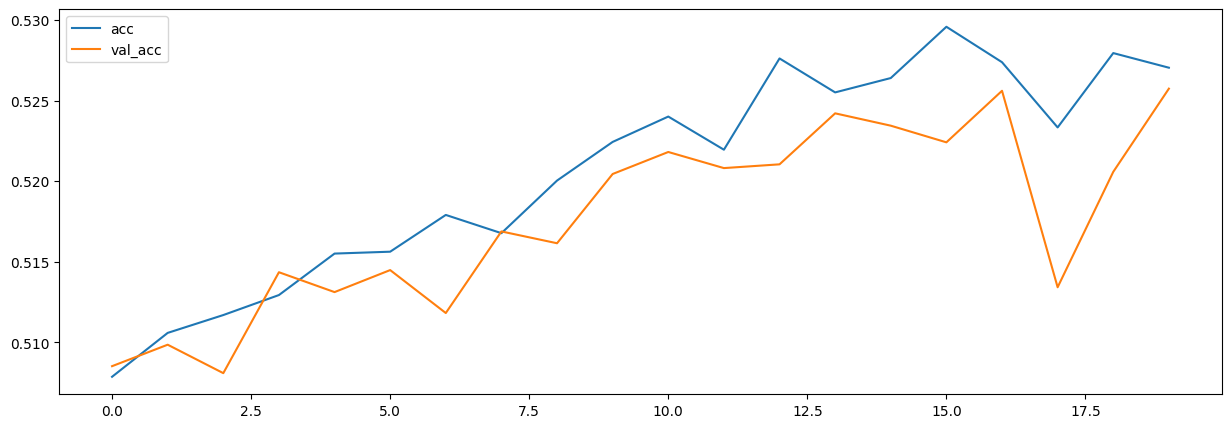

In [28]:
# 성능 시각화
plt.figure(figsize=(15,5))
plt.plot(rnn_his.history['accuracy'], label='acc')
plt.plot(rnn_his.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

### LSTM 모델 사용

In [29]:
# LSTM 신경망 쌓기

# 뼈대생성
lstm_model = Sequential()
# 입력층 쌓기
lstm_model.add(InputLayer(shape=(10,1)))
# LSTM층 쌓기
lstm_model.add(LSTM(units=64, activation='tanh'))
# MLP층 쌓기
lstm_model.add(Dense(units=64, activation='relu'))
# 출력층 쌓기
lstm_model.add(Dense(units=1, activation='sigmoid'))

In [30]:
# 학습방법 및 평가방법 설정
lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [31]:
# 학습진행
# lstm은 SimpleRNN에 비해 시간이 좀더 걸린다. 그러나 성능적인면에서는 개선
# 현재 데이터는 전처리 되지 않아서 성능의 개선이 크지는 않은편
lstm_model.fit(
    X_train_vec, y_train,
    validation_split = 0.2,
    epochs=20,
    batch_size=64
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.5205 - loss: 0.6922 - val_accuracy: 0.5325 - val_loss: 0.6903
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5303 - loss: 0.6909 - val_accuracy: 0.5338 - val_loss: 0.6903
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.5304 - loss: 0.6904 - val_accuracy: 0.5318 - val_loss: 0.6898
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.5336 - loss: 0.6899 - val_accuracy: 0.5319 - val_loss: 0.6899
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5362 - loss: 0.6895 - val_accuracy: 0.5378 - val_loss: 0.6893
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5367 - loss: 0.6892 - val_accuracy: 0.5349 - val_loss: 0.6891
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5389 - loss: 0.6887 - val_accuracy: 0.5396 - val_loss: 0.6890
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.5380 - loss: 0

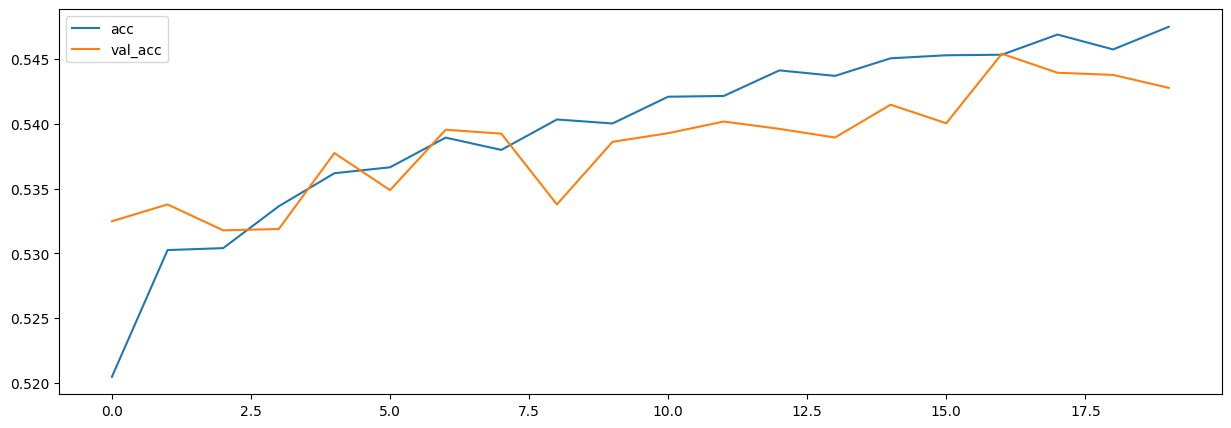

In [32]:
# 성능시각화 진행
plt.figure(figsize=(15,5))
plt.plot(lstm_model.history.history['accuracy'], label='acc')
plt.plot(lstm_model.history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

### 결과 확인
- SimpleRNN보다는 LSTM모델 성능이 조금 더 높은것을 확인
- 하지만 데이터 전처리를 하지 않았기 때문에 특정 이상의 성능을 기대하기 어렵다.
- 결국은 데이터 전처리의 유무가 결과에 영향을 크게 준다는것을 알 수 있다.

In [33]:
# 조금이라도 성능 개선을 위해 Embeding 층 쌓아보기
# 임베딩 레이어
from tensorflow.keras.layers import Embedding

In [34]:
# LSTM모델과 Embedding 레이어를 활용한 학습 진행
emb_model = Sequential()

# 임베딩 레이어 추가
emb_model.add(Embedding(5000, 50))
# 단어 사전의 수가 5000개 이기 때문에 5000으로 설정
# 벡터의 크기를 50으로 지정한 것은 정답이 아님 -> 임의의 갯수로 지정하되 너무 크거나 작지 않도록 설정

# LSTM층 쌓기
emb_model.add(LSTM(units=64, activation='relu'))
# MLP층 쌓기
emb_model.add(Dense(units=64, activation='relu'))
# 출력층 쌓기
emb_model.add(Dense(units=1, activation='sigmoid'))

In [35]:
# 학습방법 설정
emb_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [36]:
# 학습진행
emb_his = emb_model.fit(
    X_train_vec, y_train,
    validation_split = 0.2,
    epochs=20,
    batch_size=64
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.7362 - loss: 0.4912 - val_accuracy: 0.7667 - val_loss: 0.4556
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.7716 - loss: 0.4375 - val_accuracy: 0.7615 - val_loss: 0.4553
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7796 - loss: 0.4209 - val_accuracy: 0.7676 - val_loss: 0.4526
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7877 - loss: 0.4046 - val_accuracy: 0.7646 - val_loss: 0.4602
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7958 - loss: 0.3883 - val_accuracy: 0.7663 - val_loss: 0.4669
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8039 - loss: 0.3721 - val_accuracy: 0.7617 - val_loss: 0.4958
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8130 - loss: 0.3555 - val_accuracy: 0.7576 - val_loss: 0.5081
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8209 - loss: 0.3396

In [37]:
# 텍스트 데이터 -> 전처리 작업이 아주 중요하다.
# 전처리 대신 임베딩레이어를 사용 -> 임시 방편

### 결론 정리
- 텍스트 데이터를 다룰 때에는 전처리 작업이 결과에 영향을 많이 미치는것을 확인 할 수 있었다.
- 결국 데이터를 다룰 때 전처리 작업의 유무에 따라 결과에 영향을 많이 미치기 때문에 전처리 작업도 매우 중요하다.

### GRU 모델
- LSTM의 과도한 연산으로 인한 학습속도를 개선하기 위해 나온 모델
- 성능적인 측면을 개선하기 위해 나온 모델은 아니기 때문에 성능적인 측면에서 개선이 되었다고는 하기 어려움

In [38]:
# 도구 불러오기
from tensorflow.keras.layers import GRU

In [39]:
# LSTN자리에 GRU넣어서 진행

### 허깅페이스(Hugging_face)
- 인공지능 관련 데이터셋, 모델, 테스팅 공간 등을 공유하는 거대 커뮤니티 웹서비스
- 여러가지 모델을 공유하여 사용 할 수 있기 때문에 내가 다른사람이 학습시켜놓은 모델을 가져다가 사용이 가능하다.
- 내가 학습시킨 모델도 업로드하여 다른사람이 사용 할 수 있도록 설정 가능

### 시퀀스-투-시퀀스(Sequence-to-Sequence)
- 번역기에서 대표적으로 사용되는 모델
- 인코더와 디코더라는 두개의 모듈로 구성
- 인코더 : 입력된 문장의 모든 단어를 학습하여 정보를 압축하여 의미를 해석하는 모델 (의미를 해석하는 모델)
- 디코더 : 데이터를 받아서 번역된 단어를 순차적으로 출력하는 모델 (출력하는 모델)

### Transformer
  - 필요한 것은 주의 집중(Attention is All You Need) 논문으로 2017년 발표
  - 순환과 컨볼루션을 완전히 배제하고 오로지 Attention 메커니즘에만 기반을 둔 새롭고 단순한 신경망 아키텍처

  - 인코더와 디코더로 구성
  - 인코더
    - 트랜스포머는 하이퍼파라미터인 num_layers 개수의 인코더 층을 쌓음
    - 하나의 인코더 층은 크게 셀프 어텐션과 피드 포워드 신경망의 2개의 서브층(sublayer)으로 구성
      - Multi-head Self-Attention : 셀프 어텐션을 병렬적으로 사용
      - Position-wise FFNN : 일반적인 피드 포워드 신경망
    - 인코딩의 출력은 디코더로 전달

  - 디코더
    - num_layers 개수의 디코더 층을 쌓음  
    - 인코더에서 보낸 출력을 디코더 층의 연산에 사용
    - 디코더는 3개 층으로 구성
      - Masked Multi-head Self-Attention (Self Attention과 Look-ahead mask): 현재 시점의 예측에서 현재 시점보다 미래에 있는 단어들을 참고하지 못하도록 룩-어헤드 마스크(look-ahead mask)를 사용
        - 트랜스포머는 문장 행렬로 입력을 한 번에 받으므로 현재 시점의 단어를 예측하고자 할 때, 입력 문장 행렬로부터 미래 시점의 단어까지도 참고할 수 있는 현상이 발생
      - Multi-head Self-Attention (Encoder-Decoder Attention) : 멀티 헤드 어텐션을 수행
      - Position-wise FFNN

<center>  
<img src="https://arome1004.cafe24.com/images/deeplearning/transformer_attention_overview.png" width=60%>   
</center>

## Transformer 구조

> **Positional Encoding (위치 인코딩)**
> - Self-Attention 기반 모델은 입력 순서를 순차적으로 처리하지 못 함
> - 이에 대해 **<U>토큰 간 순서 정보**</U>를 알려주기 위함 (한 문장을 병렬로 처리하면서도 각 단어의 위치를 인지하게 됨)

> **Encoder Self-Attention**
> - 인코더는 **<U>입력 문장의 모든 단어 간의 관계**</U>를 계산하여, 문장 전체에서 중요한 정보를 파악

> **Add & Norm**
> - 출력에 원래 입력을 **<U>더하고, 값을 정규화**</U>하여 안정된 학습을 도움
> - ResNet - Skip Connection 개념 차용

> **Feed Forward**
> - 활성화 함수(ReLU)를 사용해 입력을 처리해서, 비선형성을 통해 모델이 더 복잡한 패턴을 학습할 수 있게 만드는 **<U>완전 연결 신경망**</U> (쉽게 MLP 떠올리면 됨)

> **Masked Decoder Self-Attention**
> - 디코더가 예측할 때 미래 단어를 **<U>참조하지 못하게 막아**</U>, 이전 단어들만을 사용해 순차적으로 예측

> **Encoder-Decoder Self-Attention**
> - Seq2Seq Attention (Bahdanau/Luong)에서 발전된 형태
> - **<U>디코더가 인코더의 출력을 참조**</U>하여,  입력 문장과의 관계를 기반으로 더 정확한 출력을 생성

In [40]:
# Positional Encoding : 어떤흐름으로 데이터가 되어있는지, 위치기반으로 의미분석
# 내가 원하는 정보를 손쉽게 얻을 수 있는 모델
# Add&Norm

In [41]:
# seq to seq

# 트랜스포머 -> gpt기반 모델
# 인코더 -> 텍스트의 흐름 의미분석 (모델1)
# 디코더 -> 들어온데이터를 출력을 담당하는 모델, 내가 원하는것에 맞게끔 출력 (모델2)

In [42]:
# trasformer 라이브러리 설치
!pip install transformers[torch]==4.42

### 문장번역 모델 사용 (Translation)

In [43]:
from transformers import pipeline

In [45]:
# 번역 모델 사용
translator = pipeline(
    task = 'translation', # 작업 단위 설정 (목적설정)
    model = 'Helsinki-NLP/opus-mt-ko-en', # 원하는 모델 불러서 지정 (모델명)
    device = 0 # GPU를 사용하겠다
)

pytorch_model.bin:   0%|          | 0.00/312M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/842k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/813k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


In [46]:
# 번역하기
text = '나는 오늘 집에가서 쉬고 싶어요'
translator(text)

[{'translation_text': 'I want to go home today and rest.'}]

In [ ]:
# 파인튜닝 -> 기존에 있던 모델을 우리의 데이터에 맞게끔 재학습시킨다. 모델을 변환시킨다.
# 출력값을 우리 데이터에 맞게끔 변환시킨다.

### Transformer 종류
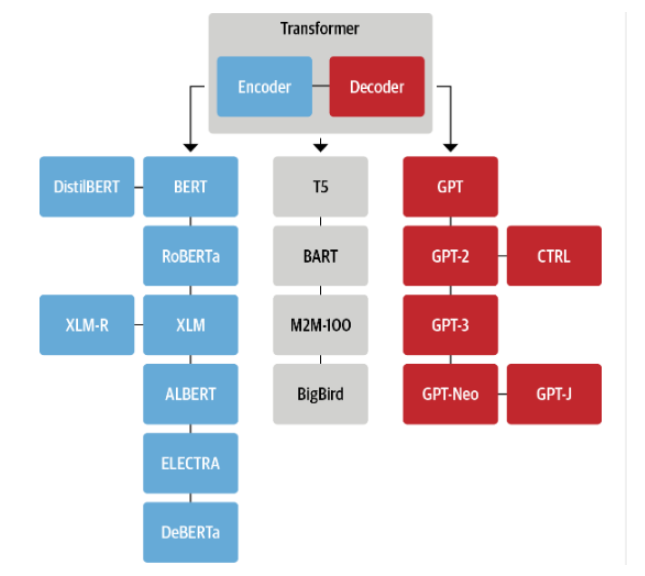

- 넓은 관점에서 트랜스포머 모델은 세 가지로 범주화 할 수 있음

> BERT 계열
> - Transformer 모델의 Encoder만 활용
> - 입력 전체를 한 번에 보고, 양방향으로 학습
> - 대표 모델 : BERT, ELECTRA 등
> - 주 사용처 : 문장 분류, 개체명 인식, 문장 유사도 등 전체 문장에 대한 이해를 요구하는 작업
>     - 빠른 추론과 가벼운 배포가 장점, 분류/검색/추천/임베딩 등 읽기 중심의 task에 많이 쓰임

> Seq2Seq 계열
> - Sequence-to-Sequence(Encoding → Decoding) 구조
> - 다양한 생성, 이해 작업에 강점을 가짐
> - 대표 모델 : T5, BART 등
> - 주 사용처 : 제로샷 분류, 요약/번역/재작성 등
>     - 다수 task(요약, 번역, 생성 등)을 하나의 모델로 운영 할 때 자주 사용

> GPT 계열
> - Transformer 모델의 Decoder만 활용
> - 입력을 순차적으로 처리하며 다음 토큰 예측(순방향)
> - 대표 모델 : GPT, GPT-2, CTRL, GPT-3, GPT-4 등
> - 주 사용처 : 텍스트 생성, 대화형 에이전트 등
>     - 창의적 생성이 장점, 프롬프트 엔지니어링이 중요할 때 선호

In [47]:
# 일반적인 BERT 모델은 한글 학습이 잘 되어 있지 않다.
# 한글은 koBERT 모델 사용

In [48]:
# 한국어 분류 모델 사용 (Ko Electra) Pipeline 로드
classifier = pipeline(
    task = 'sentiment-analysis', # 감정분석
    model = 'daekeun-ml/koelectra-small-v3-nsmc',
    device = 0
)

config.json:   0%|          | 0.00/914 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/56.5M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [49]:
# 감정 분석 진행
# 0 -> 부정 / 1 -> 긍정
test_text = '넌 정말 좋은 사람이야.'
classifier(test_text)

[{'label': '1', 'score': 0.9884359836578369}]

In [58]:
# 감정 분석 진행
# 0 -> 부정 / 1 -> 긍정
test_text1 = '우와 날씨가 참 좋다'
classifier(test_text1)

[{'label': '1', 'score': 0.9747227430343628}]